# What do the ensemble's higher moments know about its own signal?

At each grid cell and each timestep the 49 ensemble members form a distribution. This
notebook asks how much information the **shape** of that distribution carries about the
ensemble's own signal $s$ (the ensemble mean), moment by moment:

$$I(\sigma_F; s), \qquad I(\mathrm{skew}_F; s), \qquad I(\mathrm{kurt}_F; s)$$

No observations are involved anywhere -- this is entirely model-internal. The question is
whether the ensemble's uncertainty is *state-dependent*: does the spread, asymmetry or
tailedness of the forecast distribution depend on what the forecast actually is?

The null expectation is sharp. Under one forced signal plus **homoscedastic** independent
Gaussian noise, the sample mean is independent of the sample variance, skewness and
kurtosis, so all three quantities are zero. Anything above zero is state dependence.

Split out of `calc_RPC_infomeasure.ipynb`, which was getting crowded. Estimation goes
through the same `scripts/infomeasure_rpc.py` adapter, so the conventions (bits,
`noise_level=0`, max norm, rank/copula transform, $k=5$) match that notebook exactly.

In [1]:
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs

sys.path.insert(0, "../scripts")
import infomeasure_rpc as R
import infomeasure as im

rc('font', **{'family': 'sans-serif', 'serif': ['Helvetica']})
rc('text', usetex=False)
print("infomeasure", im.__version__)

infomeasure 0.6.2


## Data

`R.load_data` is `calc_RPC.ipynb` cell 3 verbatim -- the canonical preprocessing, verified
bit-identical. Ensemble is `(49, 120, 64, 128)`: 49 members, 120 monthly steps
(1962-01 to 1971-12), on a 64x128 grid.

In [2]:
DATA = "../data" if os.path.isdir("../data/ensembles") else \
    "/Users/jasperchen/Academics/Research/SNP/information-snp/data"
f, s, obs = R.load_data(data_dir=DATA)
lats, lons = f["lat"].to_numpy(), f["lon"].to_numpy()
print("ensemble", f.psl.shape, "  N=%d members, T=%d months" % f.psl.shape[:2])

# Map helper. The grid runs 0..357 degrees east; drawn with that extent in a global
# PlateCarree frame cartopy leaves a white seam at the prime meridian, so roll to
# -180..180 first. tight_layout() is avoided -- it breaks cartopy 0.25 / shapely 2.1.
PROJ = ccrs.PlateCarree()
LON180 = ((lons + 180) % 360) - 180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def panel(ax, field, cmap, norm, title):
    ax.set_global()
    h = ax.imshow(field[:, ORDER], origin="lower", extent=EXTENT, transform=PROJ,
                  cmap=cmap, norm=norm)
    # mid-grey coastlines: most of these panels are near-black under `magma`, where
    # default black outlines vanish, but a light line would vanish on the bright ones
    ax.coastlines(linewidth=0.4, color="0.6")
    ax.set_title(title, fontsize=9)
    return h

ensemble (49, 120, 64, 128)   N=49 members, T=120 months


## The three moments, and two things that would otherwise fool us

**NaN handling.** Members 10..19 are NaN for all of calendar 1971, and the published policy
fills NaNs with `0.0`. Ten hard zeros among 49 values is a severe outlier cluster, and
higher moments are far more sensitive to it than the mean is -- it would show up directly as
skewness and kurtosis. So the moments are computed **nan-aware** (`np.nanmean` of the
central powers) and only the resulting time series is zero-filled. Formulas are verified
against `scipy.stats` on complete timesteps below.

**The annual cycle.** Preprocessing removes a linear trend and *never* a seasonal cycle,
and these are monthly fields. 93% of $s$'s variance sits in the month-of-year climatology.
Any raw $I(\cdot\,;s)$ therefore largely reports *"both series know which month it is."*
Every quantity below is computed twice: as-is, and after subtracting the month-of-year
climatology from both sides.

In [3]:
def moments(A):
    # nan-aware spread, skewness and excess kurtosis over axis 0 (members)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)      # all-NaN timesteps
        d = A - np.nanmean(A, axis=0)
        m2 = np.nanmean(d ** 2, axis=0)
        m3 = np.nanmean(d ** 3, axis=0)
        m4 = np.nanmean(d ** 4, axis=0)
        out = (np.sqrt(m2), m3 / m2 ** 1.5, m4 / m2 ** 2 - 3.0)
    return tuple(np.nan_to_num(a, nan=0.0) for a in out)


SD, SK, KU = moments(f.psl.to_numpy())
SGN = np.nan_to_num(s.psl.to_numpy(), nan=0.0)          # published skipna ensemble mean
month = np.arange(SGN.shape[0]) % 12

# verify against scipy on the complete timesteps of one column
from scipy.stats import skew as _sk, kurtosis as _ku
_sub = f.psl.to_numpy()[:, :, 32, 21]
_ok = ~np.isnan(_sub).any(axis=0)
_m = moments(_sub)
print("vs scipy on %d complete timesteps:  std %.1e   skew %.1e   kurt %.1e"
      % (_ok.sum(),
         np.max(np.abs(_m[0][_ok] - np.std(_sub[:, _ok], axis=0))),
         np.max(np.abs(_m[1][_ok] - _sk(_sub[:, _ok], axis=0))),
         np.max(np.abs(_m[2][_ok] - _ku(_sub[:, _ok], axis=0)))))


def deseason(a):
    out = a.copy()
    for m in range(12):
        sel = month == m
        out[sel] = a[sel] - a[sel].mean(axis=0, keepdims=True)
    return out


def seas_frac(a):
    clim = np.zeros_like(a)
    for m in range(12):
        sel = month == m
        clim[sel] = a[sel].mean(axis=0, keepdims=True)
    v = a.var(axis=0)
    return float(np.nanmean(np.where(v > 0, clim.var(axis=0) / np.where(v > 0, v, 1), np.nan)))


print("\nfraction of variance in the month-of-year climatology")
for nm, a in (("s (mean)", SGN), ("spread", SD), ("skewness", SK), ("kurtosis", KU)):
    print("  %-12s %.3f" % (nm, seas_frac(a)))

# With only 49 members, higher moments are themselves noisy. These are the sampling
# standard deviations expected for a Gaussian sample of size N -- worth comparing against
# the variability actually present before reading anything into skew or kurtosis.
N = f.psl.shape[0]
print("\nGaussian sampling noise at N=%d vs observed variability" % N)
print("  skewness : noise sd %.2f   observed sd %.2f" % (np.sqrt(6 / N), SK.std()))
print("  kurtosis : noise sd %.2f   observed sd %.2f" % (np.sqrt(24 / N), KU.std()))

vs scipy on 108 complete timesteps:  std 2.8e-14   skew 1.1e-15   kurt 5.3e-15

fraction of variance in the month-of-year climatology
  s (mean)     0.934
  spread       0.665
  skewness     0.227
  kurtosis     0.128

Gaussian sampling noise at N=49 vs observed variability
  skewness : noise sd 0.35   observed sd 0.43
  kurtosis : noise sd 0.70   observed sd 0.78


## The grids

Six fields: three moments $\times$ (as-is, deseasonalised). Each grid cell gets its own
10-permutation null, and only the **excess** $I - \mathrm{null}$ is reported -- a bare MI at
$T=120$ is not interpretable, and the null differs from field to field.

A cold run is about 5 minutes, so it is cached.

In [4]:
CACHE = "../data/ensemble_moments_cache.npz"
MOMENTS = [("spread", SD), ("skewness", SK), ("kurtosis", KU)]
VERSIONS = ["as-is", "deseasonalised"]
N_PERM = 10

if os.path.exists(CACHE):
    _z = np.load(CACHE)
    EX = {k: _z[k] for k in _z.files}
    print("loaded cache", CACHE)
else:
    SGN_ds = deseason(SGN)
    EX = {}
    for nm, M in MOMENTS:
        for tag, A, B in (("as-is", M, SGN), ("deseasonalised", deseason(M), SGN_ds)):
            I = np.empty(SGN.shape[1:])
            NL = np.empty(SGN.shape[1:])
            for la in range(SGN.shape[1]):
                for lo in range(SGN.shape[2]):
                    x, y = A[:, la, lo], B[:, la, lo]
                    I[la, lo] = R.mi_bits(x, y, "ksg", param=5)
                    rng = np.random.default_rng(la * 1000 + lo)
                    NL[la, lo] = np.mean([R.mi_bits(x, rng.permutation(y), "ksg", param=5)
                                          for _ in range(N_PERM)])
            EX["%s|%s" % (nm, tag)] = I - NL
            EX["%s|%s|I" % (nm, tag)] = I
            EX["%s|%s|null" % (nm, tag)] = NL
            print("  done %-9s %s" % (nm, tag))
    np.savez_compressed(CACHE, **EX)
    print("cached ->", CACHE)

print("\n%-10s %-15s %8s %8s %9s %9s %s"
      % ("moment", "version", "I", "null", "excess", "lambda", "excess>0 (area)"))
for nm, _ in MOMENTS:
    for tag in VERSIONS:
        ex = EX["%s|%s" % (nm, tag)]
        print("%-10s %-15s %8.4f %8.4f %+9.4f %9.3f %11.1f%%"
              % (nm, tag, np.nanmean(EX["%s|%s|I" % (nm, tag)]),
                 np.nanmean(EX["%s|%s|null" % (nm, tag)]), np.nanmean(ex),
                 R.lam(max(np.nanmean(ex), 0)),
                 100 * R.area_weighted_fraction(ex, lats, threshold=0.0)))
print("\n(50% area would be expected by chance; lambda uses the mean excess)")

loaded cache ../data/ensemble_moments_cache.npz

moment     version                I     null    excess    lambda excess>0 (area)
spread     as-is             0.4776   0.0313   +0.4463     0.679        97.5%
spread     deseasonalised    0.0526   0.0322   +0.0205     0.167        59.0%
skewness   as-is             0.1064   0.0315   +0.0749     0.314        74.3%
skewness   deseasonalised    0.0375   0.0316   +0.0059     0.091        53.2%
kurtosis   as-is             0.0495   0.0319   +0.0176     0.155        58.6%
kurtosis   deseasonalised    0.0319   0.0316   +0.0003     0.019        49.0%

(50% area would be expected by chance; lambda uses the mean excess)


## Maps

One row per moment, as-is on the left and deseasonalised on the right, on a shared colour
scale so the rows are directly comparable.

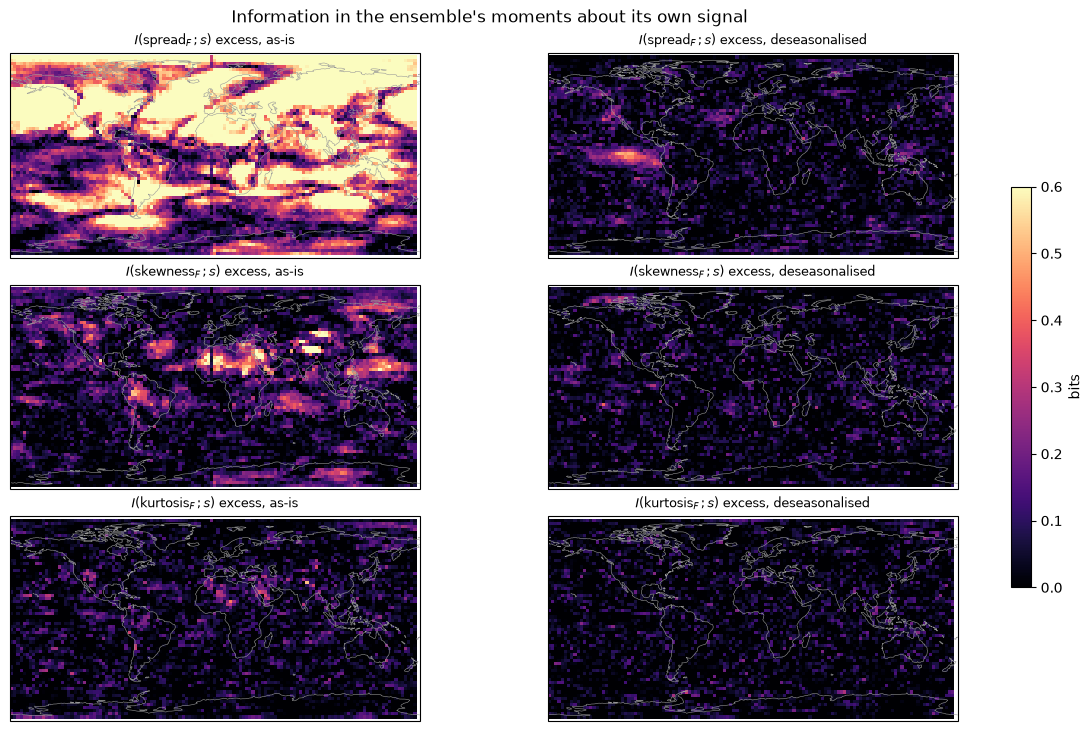

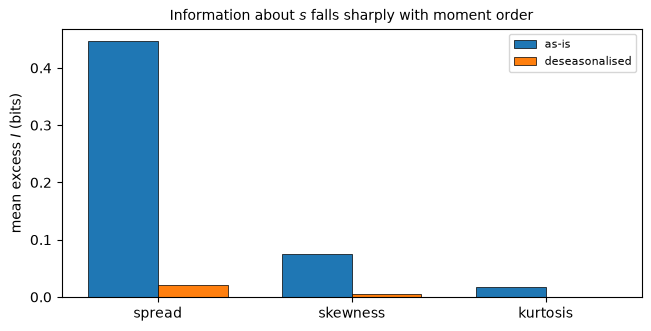

In [5]:
fig, axs = plt.subplots(3, 2, figsize=(12, 7.2), layout="constrained",
                        subplot_kw={"projection": PROJ})
norm = Normalize(0, 0.6)
for i, (nm, _) in enumerate(MOMENTS):
    for j, tag in enumerate(VERSIONS):
        ex = EX["%s|%s" % (nm, tag)]
        h = panel(axs[i, j], ex, "magma", norm,
                  "$I(\\mathrm{%s}_F\\,;s)$ excess, %s" % (nm, tag))
fig.colorbar(h, ax=axs, shrink=0.6, label="bits")
fig.suptitle("Information in the ensemble's moments about its own signal", fontsize=12)
plt.show()

# and the summary, which is easier to read as numbers than as maps
fig, ax = plt.subplots(figsize=(6.4, 3.2), layout="constrained")
w, xs = 0.36, np.arange(len(MOMENTS))
for j, tag in enumerate(VERSIONS):
    ax.bar(xs + (j - 0.5) * w,
           [np.nanmean(EX["%s|%s" % (nm, tag)]) for nm, _ in MOMENTS],
           w, label=tag, edgecolor="k", linewidth=0.5)
ax.set_xticks(xs)
ax.set_xticklabels([nm for nm, _ in MOMENTS])
ax.set_ylabel("mean excess $I$ (bits)")
ax.set_title("Information about $s$ falls sharply with moment order", fontsize=10)
ax.legend(fontsize=8)
ax.axhline(0, color="k", lw=0.5)
plt.show()

## The same six panels as Pearson correlation

Mutual information is unsigned and, because the adapter rank-transforms both variables,
it responds to *any* monotone relationship as well as non-monotone ones. Pearson $r$ sees
only the linear part -- but it keeps the **sign**, which the MI throws away. Plotting both
therefore says more than either alone: agreement means the dependence is essentially
linear, and disagreement localises where it is not.

The colour scale is symmetric about zero and spans $\pm0.6$, matching the $0$-$0.6$ range
of the MI panels above so the two figures can be read against each other.

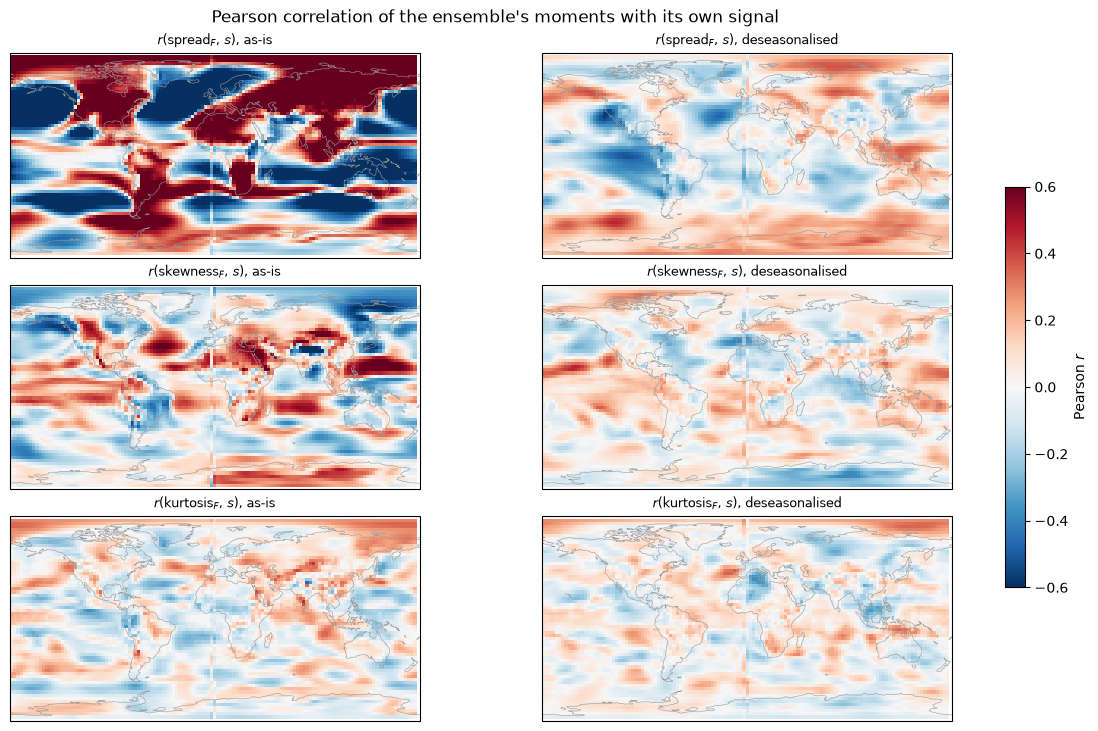

naive 95% threshold |r| > 0.181 at T=120 (ignores autocorrelation)

moment     version           mean r  mean|r| %|r|>crit  mean lam corr(|r|,lam)
spread     as-is             +0.066    0.438     78.1%     0.603     0.744
spread     deseasonalised    +0.019    0.146     30.9%     0.160     0.377
skewness   as-is             +0.009    0.186     44.6%     0.256     0.614
skewness   deseasonalised    +0.016    0.102     16.8%     0.133     0.221
kurtosis   as-is             +0.013    0.111     19.6%     0.156     0.292
kurtosis   deseasonalised    +0.012    0.085      8.6%     0.121     0.160

mean r for spread vs signal (as-is) by |lat| band -- where the sign lives:
   0-15 deg : -0.021
  15-30 deg : -0.001
  30-60 deg : -0.017
  60-90 deg : +0.243


In [6]:
def pearson(A, B):
    # correlation along the time axis at every grid cell, fully vectorised
    a = A - A.mean(axis=0, keepdims=True)
    b = B - B.mean(axis=0, keepdims=True)
    den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1), np.nan)


SGN_ds = deseason(SGN)
RR = {}
for nm, M in MOMENTS:
    RR["%s|as-is" % nm] = pearson(M, SGN)
    RR["%s|deseasonalised" % nm] = pearson(deseason(M), SGN_ds)

T = SGN.shape[0]
crit = 1.96 / np.sqrt(T - 3)      # naive 95% threshold; ignores autocorrelation

fig, axs = plt.subplots(3, 2, figsize=(12, 7.2), layout="constrained",
                        subplot_kw={"projection": PROJ})
rnorm = Normalize(-0.6, 0.6)
for i, (nm, _) in enumerate(MOMENTS):
    for j, tag in enumerate(VERSIONS):
        h = panel(axs[i, j], RR["%s|%s" % (nm, tag)], "RdBu_r", rnorm,
                  "$r(\\mathrm{%s}_F,\\,s)$, %s" % (nm, tag))
fig.colorbar(h, ax=axs, shrink=0.6, label="Pearson $r$")
fig.suptitle("Pearson correlation of the ensemble's moments with its own signal",
             fontsize=12)
plt.show()

print("naive 95%% threshold |r| > %.3f at T=%d (ignores autocorrelation)\n" % (crit, T))
print("%-10s %-15s %8s %8s %9s %9s %9s"
      % ("moment", "version", "mean r", "mean|r|", "%|r|>crit", "mean lam", "corr(|r|,lam)"))
for nm, _ in MOMENTS:
    for tag in VERSIONS:
        r = RR["%s|%s" % (nm, tag)]
        lam = R.lam(EX["%s|%s" % (nm, tag)])          # pointwise, excess clipped at 0
        m = np.isfinite(r) & np.isfinite(lam)
        print("%-10s %-15s %+8.3f %8.3f %8.1f%% %9.3f %9.3f"
              % (nm, tag, np.nanmean(r), np.nanmean(np.abs(r)),
                 100 * R.area_weighted_fraction(np.abs(r), lats, threshold=crit),
                 np.nanmean(lam), np.corrcoef(np.abs(r)[m], lam[m])[0, 1]))

print("\nmean r for spread vs signal (as-is) by |lat| band -- where the sign lives:")
r_sd = RR["spread|as-is"]
for a, b in [(0, 15), (15, 30), (30, 60), (60, 90)]:
    sel = (np.abs(lats) >= a) & (np.abs(lats) < b)
    print("  %2d-%2d deg : %+.3f" % (a, b, np.nanmean(r_sd[sel])))

### What the correlation adds

**The relationship changes sign regionally, and MI cannot see that.** For as-is spread the
mean $r$ is only $+0.066$ while the mean $|r|$ is $0.438$ -- large local correlations that
very nearly cancel globally. Broken down by latitude, $r$ is flat near zero through the
tropics and midlatitudes ($-0.02$, $-0.00$, $-0.02$) and clearly positive poleward of
$60^\circ$ ($+0.243$): at high latitudes a higher pressure signal really does come with a
wider ensemble. That structure is invisible in the MI maps, which are non-negative by
construction.

**Otherwise the two measures agree, and agree less as the signal weakens.** The spatial
correlation between $|r|$ and the MI-implied $\lambda$ is $0.744$ for as-is spread, falling
to $0.614$ for skewness, $0.292$ for kurtosis, and $0.377 / 0.221 / 0.160$ for the
deseasonalised versions -- tracking exactly the collapse the MI analysis found. Where there
is signal, both measures find it in the same places; where there is none, they disagree
because both are describing noise.

**$\lambda$ sits consistently above $|r|$, and most of the gap is real.** The excess is
$+0.165$ for as-is spread against only $+0.014$ to $+0.035$ in the panels that carry
essentially no signal. Since that latter figure is the size of the offset attributable to
bias -- $\lambda$ is computed from an excess clipped at zero, so it cannot go negative and
noise survives only upward -- the much larger gap for as-is spread reflects genuine
dependence that a linear coefficient misses. The rank transform is why: it makes the MI
sensitive to any monotone relationship, not just a straight-line one.

**Practical reading:** report both. Pearson for sign and for a familiar effect size, MI for
whether any dependence exists at all. Neither alone would have shown both that the
high-latitude spread-signal link is *positive* and that the tropical link, while
sign-ambiguous, is not zero.

**Two artefacts in the figure, not findings.** The as-is spread panel saturates against the
$\pm0.6$ scale over large areas -- the scale is held there deliberately so the weak panels
stay legible, but read that panel as "strong" rather than off its colour value. And a pale
vertical line runs down the prime meridian in most panels: longitude columns 0 and 127 are
20.7% and 42.9% NaN because the wrap-around is not handled before `interp_like`, so those
two columns are the least trustworthy on every map in this notebook.


## Findings

| moment | as-is excess | area $>0$ | deseasonalised excess | area $>0$ | seasonal var. |
|---|---|---|---|---|---|
| spread | 0.446 | 97.5% | **0.021** | 59.0% | 0.665 |
| skewness | 0.075 | 74.3% | **0.006** | 53.2% | 0.227 |
| kurtosis | 0.018 | 58.6% | **0.000** | 49.0% | 0.128 |

**Almost all of the as-is signal is the shared annual cycle.** Deseasonalising leaves 5% of
the spread's excess, 8% of the skewness's, and 2% of the kurtosis's. The as-is spread map
is the giveaway -- it lights up over North America, Asia and Africa, wherever the annual
sea-level-pressure cycle is largest, not over the regions where forecast skill lives.

**Information about $s$ collapses with moment order.** Even before the seasonal control,
0.446 $\to$ 0.075 $\to$ 0.018 bits, a factor of ~25 across two moments. After it, spread
retains a marginal 0.021 bits over 59.0% of the area, skewness 0.006 over 53.2%, and
kurtosis 0.0003 over **49.0%** -- which is *below* the 50% expected by chance, i.e.
indistinguishable from no relationship at all.

**Two reasons, and they compound.** First, higher moments of 49 samples are mostly
estimation noise: the Gaussian sampling standard deviation at $N=49$ is 0.35 for skewness
against an observed 0.43, and 0.70 for excess kurtosis against an observed 0.78. Only
roughly a third of the skewness variability and a fifth of the kurtosis variability is real
structure rather than sampling noise, so there is little signal available to detect.
Second, whatever survives has to be detected from $T=120$ samples against a permutation
floor of about 0.032 bits, which is already larger than the entire deseasonalised kurtosis
signal.

**Conclusion.** Once seasonality is controlled, the ensemble's distributional shape is
essentially independent of its own signal, which is what homoscedastic
signal-plus-noise predicts. The spread retains a weak, marginally detectable dependence;
skewness barely; kurtosis not at all. Practically: $(\bar F, \sigma_F)$ is worth carrying
as a predictor, and $\mathrm{skew}_F$ and $\mathrm{kurt}_F$ are not -- at this ensemble size
and record length they are noise, and adding them would cost dimensions while contributing
nothing.

The caveat that bounds all of this: $N=49$ and $T=120$. A larger ensemble would make the
higher moments measurable, and a longer record would lower the detection floor. Nothing
here says the atmosphere has no state-dependent skewness -- only that this dataset cannot
see it.